# Part 1: Setup (run once)
Installs and downloads. Stay on disk after a session restart.

In [29]:
!pip install ultralytics -q

In [30]:
# Install (Colab). Safe to re-run.
!apt-get install -y -qq tesseract-ocr tesseract-ocr-ben > /dev/null
!pip install -q pytesseract

In [31]:
!pip install -q easyocr

In [32]:
%cd /content
!rm -rf NAFNet
!git clone https://github.com/megvii-research/NAFNet
%cd /content/NAFNet
!pip install -q addict future lmdb yapf gdown

# Tell Python where NAFNet is, instead of installing it
import sys, os
sys.path.insert(0, '/content/NAFNet')
os.environ['PYTHONPATH'] = '/content/NAFNet:' + os.environ.get('PYTHONPATH', '')

# Quick check
from basicsr.models import create_model
print("basicsr import OK")

/content
Cloning into 'NAFNet'...
remote: Enumerating objects: 521, done.
remote: Counting objects: 100% (339/339), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 521 (delta 263), reused 223 (delta 223), pack-reused 182 (from 1)
Receiving objects: 100% (521/521), 16.19 MiB | 18.61 MiB/s, done.
Resolving deltas: 100% (279/279), done.
/content/NAFNet
basicsr import OK


In [33]:
%cd /content/NAFNet
import os
from huggingface_hub import hf_hub_download

save_dir = '/content/NAFNet/experiments/pretrained_models'
os.makedirs(save_dir, exist_ok=True)

for name in ['NAFNet-GoPro-width64.pth', 'NAFNet-SIDD-width64.pth']:
    path = hf_hub_download(repo_id='nyanko7/nafnet-models', filename=name, local_dir=save_dir)
    print(f'OK  {name}  {os.path.getsize(path)/1e6:.0f} MB')

/content/NAFNet


NAFNet-GoPro-width64.pth: reconstructing file:   0%|          |  0.00B /  272MB            

NAFNet-GoPro-width64.pth: downloading bytes:           |  0.00B            

OK  NAFNet-GoPro-width64.pth  272 MB


NAFNet-SIDD-width64.pth: reconstructing file:   0%|          |  0.00B /  464MB            

NAFNet-SIDD-width64.pth: downloading bytes:           |  0.00B            

OK  NAFNet-SIDD-width64.pth  464 MB


In [34]:
%cd /content/NAFNet
!PYTHONPATH=/content/NAFNet python basicsr/demo.py -opt options/test/GoPro/NAFNet-width64.yml \
  --input_path ./demo/blurry.jpg --output_path ./demo/deblur_img.png

/content/NAFNet
Disable distributed.
 load net keys <built-in method keys of collections.OrderedDict object at 0x7e4fa59fb4c0>
2026-09-24 05:46:21,867 INFO: Model [ImageRestorationModel] is created.
inference ./demo/blurry.jpg .. finished. saved to ./demo/deblur_img.png


In [35]:
%cd /content
!git clone https://github.com/ZZZHANG-jx/DocRes.git
%cd /content/DocRes
!pip install -q einops scikit-image opencv-python-headless tqdm huggingface_hub

/content
fatal: destination path 'DocRes' already exists and is not an empty directory.
/content/DocRes


In [36]:
%cd /content/DocRes
!sed -i "s/map_location='cpu')/map_location='cpu', weights_only=False)/" inference.py
!sed -i "s/map_location='cuda:0')/map_location='cuda:0', weights_only=False)/" inference.py
!sed -i "s/torch.load(model_path)/torch.load(model_path, weights_only=False)/" data/MBD/infer.py
!sed -i "s/torch.load(args.seg_model_path)/torch.load(args.seg_model_path, weights_only=False)/" data/MBD/infer.py
!sed -i "s/np\.bool)/bool)/g; s/astype(np\.bool)/astype(bool)/g" utils.py
!grep -n "weights_only" inference.py data/MBD/infer.py

/content/DocRes
inference.py:289:        state = convert_state_dict(torch.load(args.model_path, map_location='cpu', weights_only=False)['model_state'])
inference.py:291:        state = convert_state_dict(torch.load(args.model_path, map_location='cuda:0', weights_only=False)['model_state'])    
data/MBD/infer.py:77:    checkpoint = torch.load(model_path, weights_only=False)
data/MBD/infer.py:145:    checkpoint = torch.load(args.seg_model_path, weights_only=False)


In [37]:
import os, glob, shutil
from huggingface_hub import snapshot_download

os.chdir("/content/DocRes")
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("data/MBD/checkpoint", exist_ok=True)

main_dir = snapshot_download("DaVinciCode/doctra-docres-main", allow_patterns=["*.pkl"])
mbd_dir = snapshot_download("DaVinciCode/doctra-docres-mbd", allow_patterns=["*.pkl"])

main_pkl = glob.glob(os.path.join(main_dir, "**", "*.pkl"), recursive=True)
mbd_pkl = glob.glob(os.path.join(mbd_dir, "**", "*.pkl"), recursive=True)
print("main:", main_pkl)
print("mbd:", mbd_pkl)

shutil.copy(main_pkl[0], "checkpoints/docres.pkl")
shutil.copy(mbd_pkl[0], "data/MBD/checkpoint/mbd.pkl")
!ls -lh checkpoints data/MBD/checkpoint

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

main: ['/root/.cache/huggingface/hub/models--DaVinciCode--doctra-docres-main/snapshots/1e63badacc1b20489c0c29b12437c98bda51b12e/docres.pkl']
mbd: ['/root/.cache/huggingface/hub/models--DaVinciCode--doctra-docres-mbd/snapshots/d926648477d8d8db30bd260ee5ce182f7d05a508/mbd.pkl']
checkpoints:
total 175M
-rw-r--r-- 1 root root 175M Sep 24 05:46 docres.pkl

data/MBD/checkpoint:
total 680M
-rw-r--r-- 1 root root 680M Sep 24 05:46 mbd.pkl


In [38]:
!nvidia-smi --query-gpu=memory.used,memory.total --format=csv

memory.used [MiB], memory.total [MiB]
1281 MiB, 15360 MiB


In [39]:
%cd /content/DocRes
import os
os.environ["DOCRES_MAX"] = "1024"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

!rm -rf restorted && mkdir restorted
!python inference.py --im_path ./input/for_dewarping.png --task dewarping
!python inference.py --im_path ./input/for_appearance.png --task appearance
!python inference.py --im_path ./input/for_deshadowing.jpg --task deshadowing
!ls restorted

/content/DocRes
for_appearance_appearance.png	 for_dewarping_dewarping.png
for_deshadowing_deshadowing.jpg


**Now go to Runtime → Restart session** (frees GPU memory used by the demo tests).

# Part 2: Pipeline (run top to bottom for each card)

In [40]:
%cd /content

/content


In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files
from IPython.display import display
from PIL import Image
import io

In [42]:
# Install gdown to fetch from Google Drive
!pip install gdown -q

import gdown

# Pick ONE — start with nano (fastest)
# Nano
gdown.download(id="1ZD_CEsbo3p3_dd8eAtRfRxHDV44M0djK", output="yolov8-face.pt", quiet=False)

# Medium (swap to this if nano misses faces)
# gdown.download(id="1IJZBcyMHGhzAi0G4aZLcqryqZSjPsps-", output="yolov8-face.pt", quiet=False)

from ultralytics import YOLO
model = YOLO('yolov8-face.pt')
print("Model loaded ✓")

Downloading...
From: https://drive.google.com/uc?id=1ZD_CEsbo3p3_dd8eAtRfRxHDV44M0djK
To: /content/yolov8-face.pt
100%|██████████| 24.5M/24.5M [00:00<00:00, 55.9MB/s]


Model loaded ✓


In [43]:
uploaded = files.upload()
img_name = list(uploaded.keys())[0]
img = cv2.imread(img_name)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

results = model(img_rgb)
boxes = results[0].boxes.xyxy.cpu().numpy()  # [x1, y1, x2, y2]

print(f"Faces detected: {len(boxes)}")
for i, box in enumerate(boxes):
    print(f"  Face {i}: {box.astype(int)}")

Saving 16.jpg to 16.jpg

0: 416x640 1 Face, 5.8ms
Speed: 2.8ms preprocess, 5.8ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 640)
Faces detected: 1
  Face 0: [101 242 190 371]


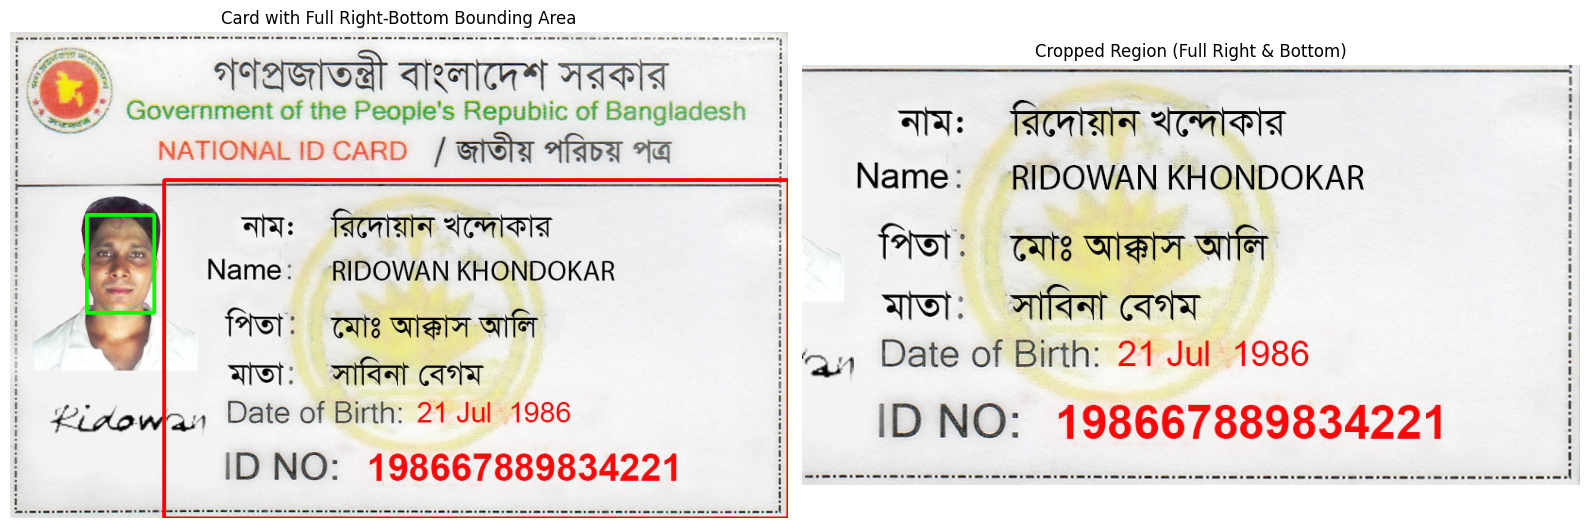

In [44]:
import cv2
import matplotlib.pyplot as plt

def get_text_roi_from_face_to_edges(image, face_box):
    """
    Keeps the validated top and left bounds from the face anchor,
    and extends fully to the bottom and right edges of the image.
    """
    fx1, fy1, fx2, fy2 = face_box
    img_h, img_w = image.shape[:2]
    face_h = fy2 - fy1
    face_w = fx2 - fx1

    # Left boundary: Just right of the face photo
    crop_x1 = int(max(0, fx2 + (0.15 * face_w)))

    # Right boundary: All the way to the card edge
    crop_x2 = img_w

    # Top boundary: Above face level, below the header
    crop_y1 = int(max(0, fy1 - (0.35 * face_h)))

    # Bottom boundary: All the way to the card bottom
    crop_y2 = img_h

    return (crop_x1, crop_y1, crop_x2, crop_y2)

if len(boxes) == 0:
    print("❌ No face detected.")
else:
    # Pick primary face by maximum bounding box area
    primary_face = max(boxes, key=lambda b: (b[2] - b[0]) * (b[3] - b[1]))

    tx1, ty1, tx2, ty2 = get_text_roi_from_face_to_edges(img_rgb, primary_face)
    cropped_text_region = img_rgb[ty1:ty2, tx1:tx2]

    # --- Visualization ---
    vis_img = img_rgb.copy()

    # Draw face (Green) and full right-bottom text ROI (Blue)
    fx1, fy1, fx2, fy2 = primary_face.astype(int)
    cv2.rectangle(vis_img, (fx1, fy1), (fx2, fy2), (0, 255, 0), 3)
    cv2.rectangle(vis_img, (tx1, ty1), (tx2, ty2), (255, 0, 0), 3)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(vis_img)
    axes[0].set_title("Card with Full Right-Bottom Bounding Area")
    axes[0].axis("off")

    axes[1].imshow(cropped_text_region)
    axes[1].set_title("Cropped Region (Full Right & Bottom)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

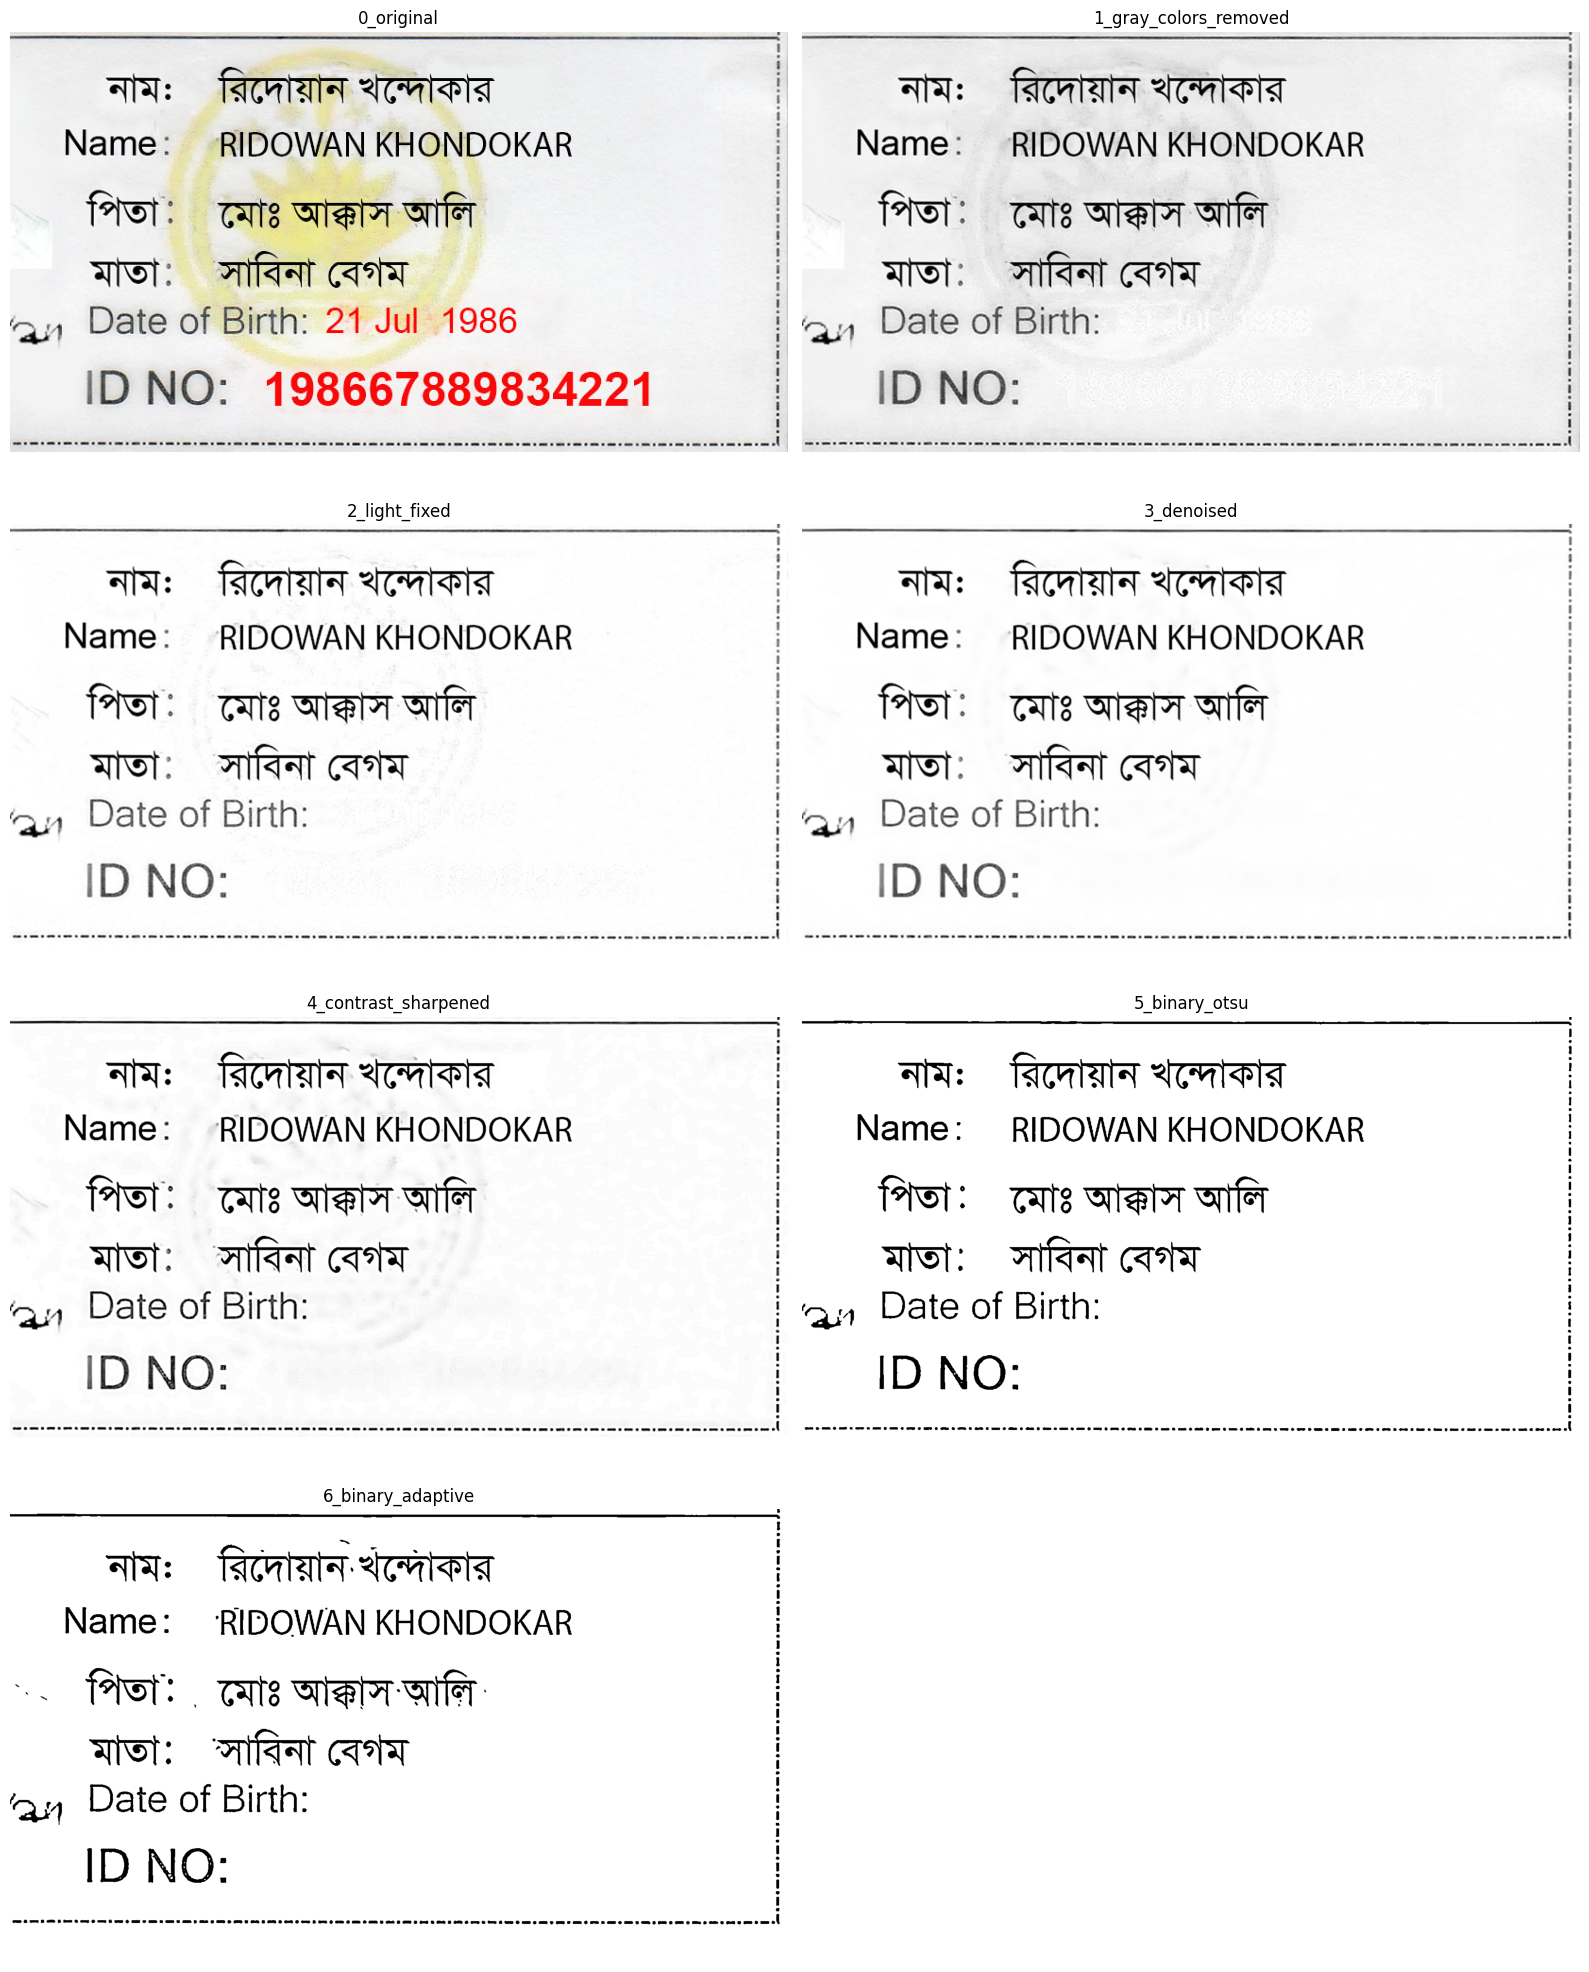

Saved all versions ✓


In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def upscale(img, target_height=900):
    """Make small crops bigger so letters have more pixels. OCR likes ~30px tall text."""
    h, w = img.shape[:2]
    if h >= target_height:
        return img
    scale = target_height / h
    return cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)


def to_gray_drop_colors(img_rgb):
    """
    Take the brightest of R, G, B for each pixel.
    Dark text is dark in all three channels, so it stays dark.
    The pink circle and green pattern are bright in at least one channel,
    so they turn light and fade into the background.
    """
    return np.max(img_rgb, axis=2).astype(np.uint8)


def remove_uneven_light(gray, blur_size=51):
    """
    Estimate the background (lighting, glare, shadows) with a big blur,
    then divide it out so the background becomes flat white.
    """
    background = cv2.medianBlur(gray, blur_size)
    norm = cv2.divide(gray, background, scale=255)
    return norm


def denoise(gray, strength=10):
    """Non-local means: removes grain and JPEG noise but keeps letter edges."""
    return cv2.fastNlMeansDenoising(gray, None, h=strength,
                                    templateWindowSize=7, searchWindowSize=21)


def boost_contrast(gray):
    """CLAHE: raises contrast in small tiles, so faint text gets darker."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)


def sharpen(gray, amount=1.0, radius=3):
    """Unsharp mask: makes slightly blurry letter edges crisper."""
    blurred = cv2.GaussianBlur(gray, (0, 0), radius)
    return cv2.addWeighted(gray, 1 + amount, blurred, -amount, 0)


def binarize_otsu(gray):
    """One global threshold for the whole image. Good when lighting is even."""
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return bw


def binarize_adaptive(gray, block_size=31, C=15):
    """A separate threshold for each small area. Better with uneven lighting."""
    return cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY, block_size, C)


def remove_specks(bw, min_area=15):
    """Delete tiny black dots left after thresholding (not real letters)."""
    inv = 255 - bw
    n, labels, stats, _ = cv2.connectedComponentsWithStats(inv, connectivity=8)
    keep = np.zeros_like(inv)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            keep[labels == i] = 255
    return 255 - keep


def clean_for_ocr(img_rgb):
    """
    Runs the full cleanup and returns every step, so you can
    feed each version to OCR and see which one reads best.
    """
    steps = {}
    steps["0_original"] = img_rgb

    big = upscale(img_rgb)
    gray = to_gray_drop_colors(big)
    steps["1_gray_colors_removed"] = gray

    flat = remove_uneven_light(gray)
    steps["2_light_fixed"] = flat

    clean = denoise(flat)
    steps["3_denoised"] = clean

    contrast = boost_contrast(clean)
    sharp = sharpen(contrast)
    steps["4_contrast_sharpened"] = sharp

    steps["5_binary_otsu"] = remove_specks(binarize_otsu(sharp))
    steps["6_binary_adaptive"] = remove_specks(binarize_adaptive(sharp))
    return steps


def show_steps(steps):
    n = len(steps)
    cols = 2
    rows = (n + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    axes = axes.flatten()
    for ax, (name, im) in zip(axes, steps.items()):
        ax.imshow(im, cmap=None if im.ndim == 3 else "gray")
        ax.set_title(name)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# ---- Run on the crop from the previous cell ----
steps = clean_for_ocr(cropped_text_region)
show_steps(steps)

# Save every version so you can run OCR on each one
for name, im in steps.items():
    out = cv2.cvtColor(im, cv2.COLOR_RGB2BGR) if im.ndim == 3 else im
    cv2.imwrite(f"clean_{name}.png", out)
print("Saved all versions ✓")

Running on: cuda
✓ deblur: loaded NAFNet-GoPro-width64.pth
✓ denoise: loaded NAFNet-SIDD-width64.pth
Deblur time : 0.55s
Denoise time: 0.54s


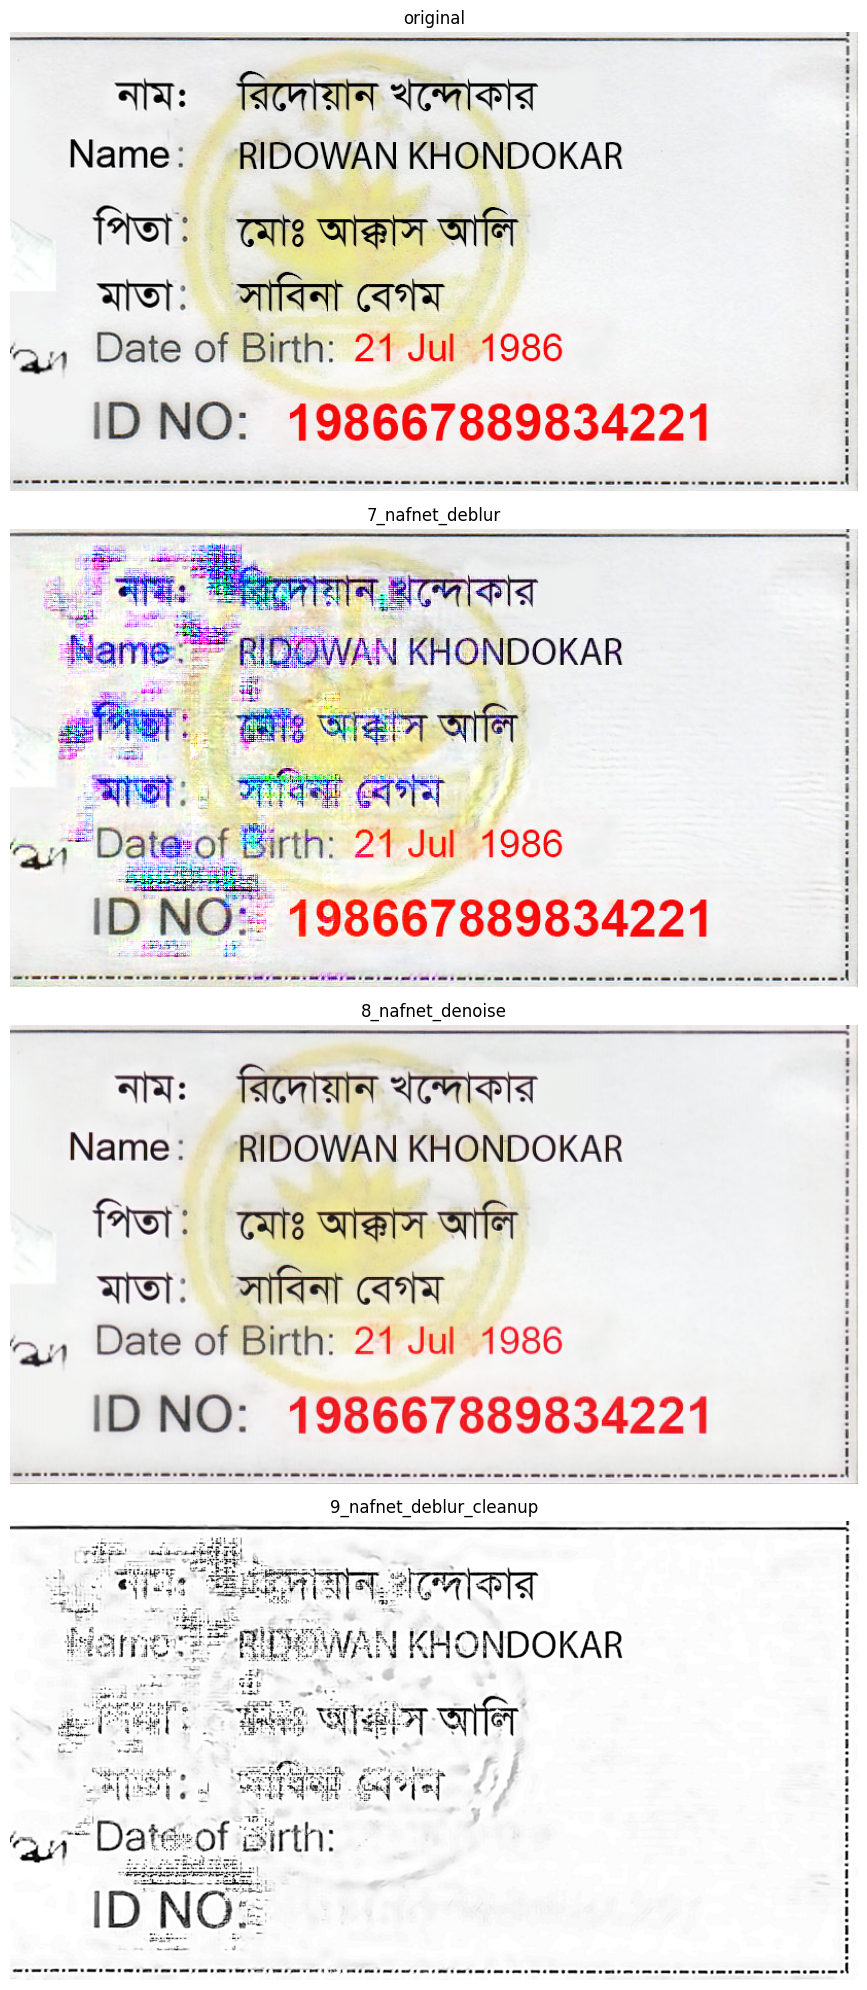

Saved NAFNet versions ✓  -> now re-run the Tesseract, EasyOCR and comparison cells


In [46]:
# ===== NAFNet: deblur + denoise the cropped text region =====
import os
import sys
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

NAFNET_DIR = "/content/NAFNet"
WEIGHTS_DIR = f"{NAFNET_DIR}/experiments/pretrained_models"
sys.path.insert(0, NAFNET_DIR)

from basicsr.models.archs.NAFNet_arch import NAFNet, NAFNetLocal

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", DEVICE)


# Settings copied from the repo's test .yml files, so they match the weights exactly.
# For each job, the first file that exists is used (width32 is a smaller backup).
MODEL_SPECS = {
    "deblur": [   # GoPro: trained to remove motion/camera blur
        dict(file="NAFNet-GoPro-width64.pth", local=True, width=64,
             enc=[1, 1, 1, 28], mid=1, dec=[1, 1, 1, 1]),
    ],
    "denoise": [  # SIDD: trained to remove phone-camera noise
        dict(file="NAFNet-SIDD-width64.pth", local=False, width=64,
             enc=[2, 2, 4, 8], mid=12, dec=[2, 2, 2, 2]),
        dict(file="NAFNet-SIDD-width32.pth", local=False, width=32,
             enc=[2, 2, 4, 8], mid=12, dec=[2, 2, 2, 2]),
    ],
}


def load_nafnet(kind):
    """Returns the loaded model, or None if no weight file for this job is found."""
    for spec in MODEL_SPECS[kind]:
        path = f"{WEIGHTS_DIR}/{spec['file']}"
        # Skip missing files and tiny files (a failed Drive download saves an error page)
        if not os.path.exists(path) or os.path.getsize(path) < 1_000_000:
            continue
        Net = NAFNetLocal if spec["local"] else NAFNet   # GoPro uses NAFNetLocal
        net = Net(img_channel=3, width=spec["width"], enc_blk_nums=spec["enc"],
                  middle_blk_num=spec["mid"], dec_blk_nums=spec["dec"])
        ckpt = torch.load(path, map_location="cpu")
        state = ckpt.get("params", ckpt.get("params_ema", ckpt))  # weights are stored under 'params'
        net.load_state_dict(state, strict=True)
        print(f"✓ {kind}: loaded {spec['file']}")
        return net.eval().to(DEVICE)
    print(f"✗ {kind}: no weight file found in {WEIGHTS_DIR} -> skipping {kind}")
    return None


@torch.no_grad()
def run_nafnet(net, img_rgb):
    """RGB uint8 image in -> RGB uint8 image out (same size)."""
    x = torch.from_numpy(img_rgb).float().div(255.0)       # H,W,C in 0..1
    x = x.permute(2, 0, 1).unsqueeze(0).to(DEVICE)         # 1,C,H,W
    y = net(x)                                             # model pads/crops size itself
    y = y.clamp(0, 1).squeeze(0).permute(1, 2, 0).cpu().numpy()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return (y * 255.0).round().astype(np.uint8)


def timed(fn, *args):
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    out = fn(*args)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    return out, time.perf_counter() - start


# ---- Load both models ----
deblur_net = load_nafnet("deblur")
denoise_net = load_nafnet("denoise")

# ---- Run on the ORIGINAL crop (not upscaled: the models were trained on real photo sizes) ----
src = np.ascontiguousarray(cropped_text_region)
new_versions = {}

if deblur_net is not None:
    _ = run_nafnet(deblur_net, src[:64, :64])          # warm-up so timings are fair
    deblurred, t = timed(run_nafnet, deblur_net, src)
    print(f"Deblur time : {t:.2f}s")
    new_versions["7_nafnet_deblur"] = deblurred
    # NAFNet deblur followed by the OpenCV cleanup from the earlier cell
    new_versions["9_nafnet_deblur_cleanup"] = clean_for_ocr(deblurred)["4_contrast_sharpened"]

if denoise_net is not None:
    _ = run_nafnet(denoise_net, src[:64, :64])
    denoised, t = timed(run_nafnet, denoise_net, src)
    print(f"Denoise time: {t:.2f}s")
    new_versions["8_nafnet_denoise"] = denoised

# ---- Add the new versions to `steps` so the Tesseract / EasyOCR / comparison
#      cells include them automatically when you re-run them ----
steps.update(new_versions)

# ---- Show results ----
show = {"original": src, **dict(sorted(new_versions.items()))}
fig, axes = plt.subplots(len(show), 1, figsize=(12, 5 * len(show)), squeeze=False)
for row, (name, im) in enumerate(show.items()):
    axes[row, 0].imshow(im, cmap=None if im.ndim == 3 else "gray")
    axes[row, 0].set_title(name)
    axes[row, 0].axis("off")
plt.tight_layout()
plt.show()

# Save the new versions
for name, im in new_versions.items():
    out = cv2.cvtColor(im, cv2.COLOR_RGB2BGR) if im.ndim == 3 else im
    cv2.imwrite(f"clean_{name}.png", out)
print("Saved NAFNet versions ✓  -> now re-run the Tesseract, EasyOCR and comparison cells")

Running on: cuda
DocRes model loaded ✓
appearance   : 0.54s
deblurring   : 0.44s
deshadowing  : 0.57s
binarization : 0.47s


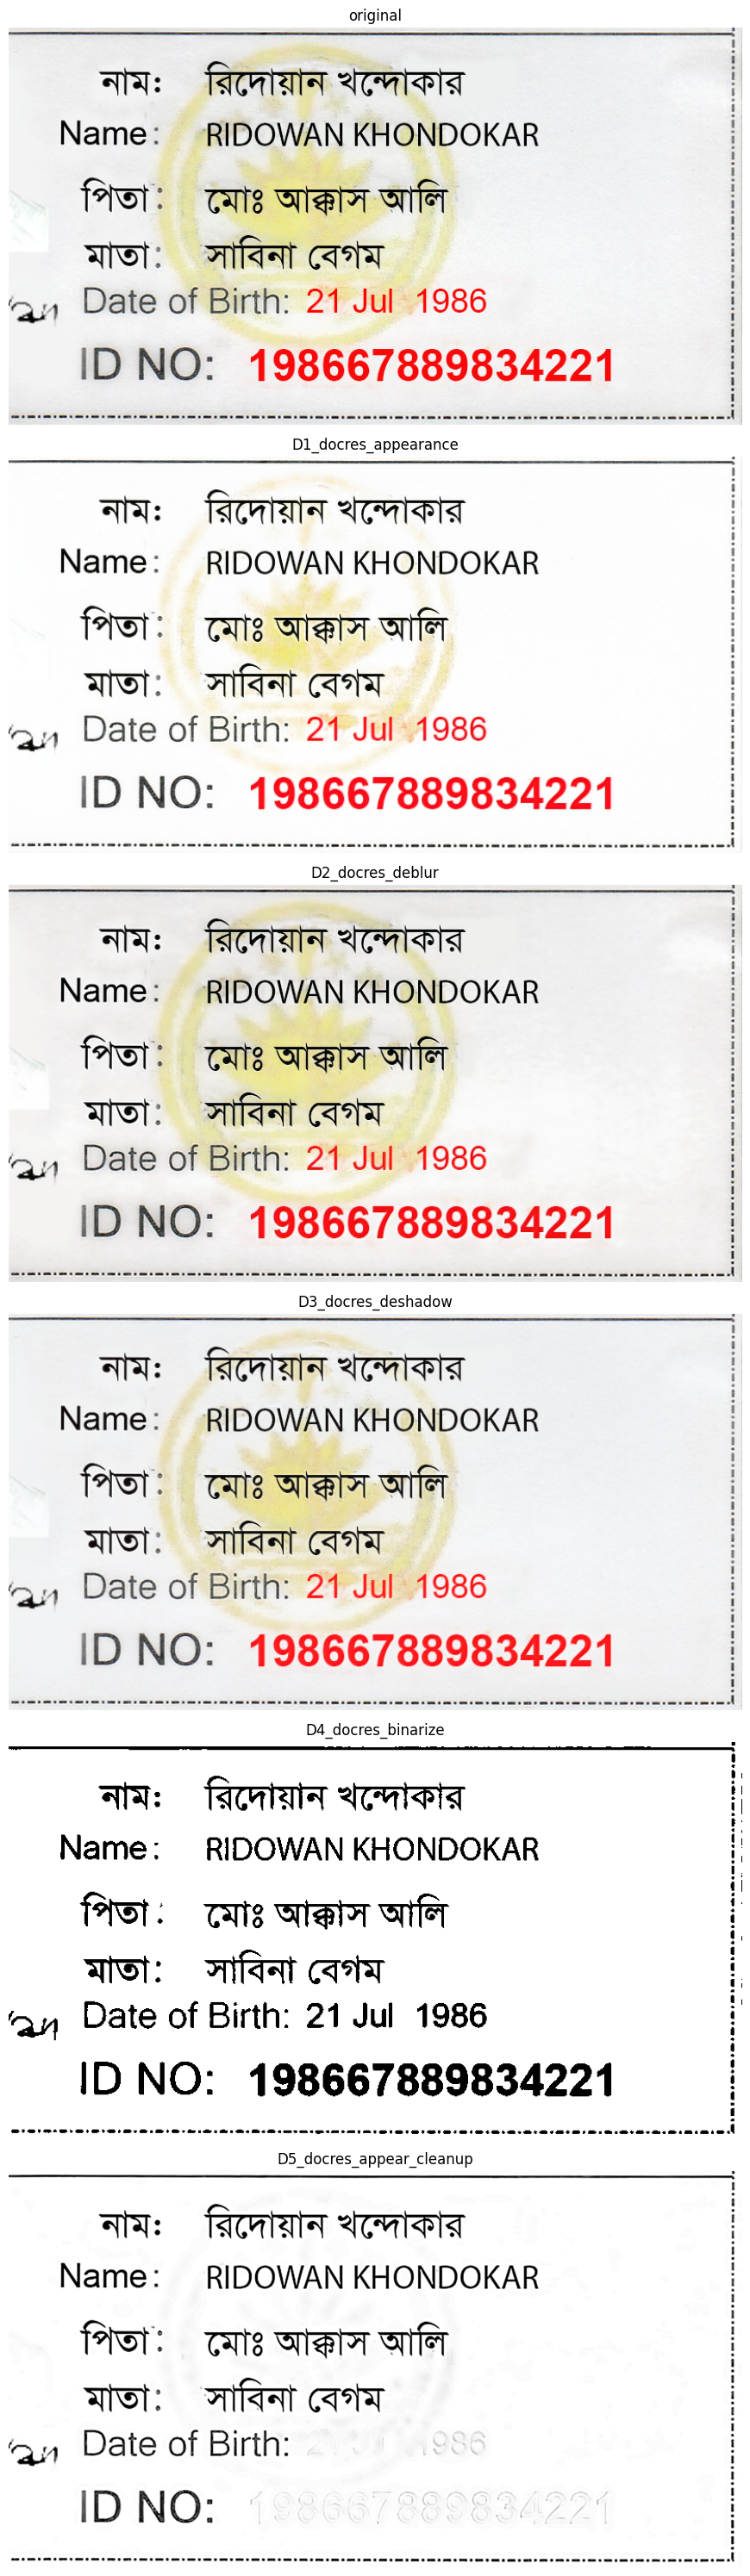

Saved DocRes versions ✓  -> now re-run the Tesseract, EasyOCR and comparison cells


In [47]:
# ===== DocRes: document restoration on the cropped text region =====
import os
import sys
import time
import types
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt

DOCRES_DIR = "/content/DocRes"
MODEL_PATH = f"{DOCRES_DIR}/checkpoints/docres.pkl"
TMP_PATH = os.path.abspath("_docres_input.png")   # DocRes reads images from a file path
os.environ.setdefault("DOCRES_MAX", "1024")       # lower to "768" if you run out of GPU memory

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", DEVICE)

# Free GPU memory used by the NAFNet models (their outputs are already saved in `steps`)
for _name in ("deblur_net", "denoise_net"):
    if _name in globals():
        del globals()[_name]
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
if DEVICE.type == "cpu":
    print("⚠ DocRes runs in half precision and is meant for GPU. Switch to a GPU runtime.")

# ---- Import DocRes's own inference.py ----
# DocRes uses generic module names (utils, models, data). Remove any other modules
# with those names so Python loads the DocRes ones.
for name in list(sys.modules):
    if name.split(".")[0] in ("utils", "models", "data", "model", "MBD", "inference"):
        mod_file = getattr(sys.modules[name], "__file__", None) or ""
        if not mod_file.startswith(DOCRES_DIR):
            del sys.modules[name]
if DOCRES_DIR not in sys.path:
    sys.path.insert(0, DOCRES_DIR)

_prev_cwd = os.getcwd()
os.chdir(DOCRES_DIR)                 # DocRes uses paths relative to its own folder
try:
    import inference as docres
finally:
    os.chdir(_prev_cwd)

docres.DEVICE = DEVICE               # its functions read this global

# ---- Load the model (same settings as DocRes's model_init) ----
docres_model = docres.model_init(types.SimpleNamespace(model_path=MODEL_PATH))
print("DocRes model loaded ✓")

# One model, several jobs. Dewarping is left out: it is for a full bent page,
# not an already-cropped text region.
DOCRES_TASKS = {
    "appearance":   docres.appearance,    # whitens background, removes colour tint / stains
    "deblurring":   docres.deblurring,    # sharpens blurry text
    "deshadowing":  docres.deshadowing,   # removes shadows and uneven light
    "binarization": docres.binarization,  # black text on white background
}


def run_docres(task, img_rgb):
    """RGB image in -> restored image out (RGB, or grayscale for binarization)."""
    cv2.imwrite(TMP_PATH, cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    _, _, _, out = DOCRES_TASKS[task](docres_model, TMP_PATH)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
    elapsed = time.perf_counter() - start
    if out.ndim == 3:
        out = cv2.cvtColor(out, cv2.COLOR_BGR2RGB)
    return np.ascontiguousarray(out), elapsed


# ---- Run every task on the ORIGINAL crop ----
src = np.ascontiguousarray(cropped_text_region)
_ = run_docres("appearance", src)    # warm-up so timings are fair

docres_versions = {}
names = {
    "appearance":   "D1_docres_appearance",
    "deblurring":   "D2_docres_deblur",
    "deshadowing":  "D3_docres_deshadow",
    "binarization": "D4_docres_binarize",
}
for task, vname in names.items():
    out, t = run_docres(task, src)
    docres_versions[vname] = out
    print(f"{task:<13}: {t:.2f}s")

# DocRes appearance followed by the OpenCV cleanup from the earlier cell
docres_versions["D5_docres_appear_cleanup"] = clean_for_ocr(
    docres_versions["D1_docres_appearance"])["4_contrast_sharpened"]

os.remove(TMP_PATH)

# ---- Add to `steps` so the Tesseract / EasyOCR / comparison cells include them ----
steps.update(docres_versions)

# ---- Show results ----
show = {"original": src, **docres_versions}
fig, axes = plt.subplots(len(show), 1, figsize=(12, 5 * len(show)), squeeze=False)
for row, (name, im) in enumerate(show.items()):
    axes[row, 0].imshow(im, cmap=None if im.ndim == 3 else "gray")
    axes[row, 0].set_title(name)
    axes[row, 0].axis("off")
plt.tight_layout()
plt.show()

# Save the new versions
for name, im in docres_versions.items():
    out = cv2.cvtColor(im, cv2.COLOR_RGB2BGR) if im.ndim == 3 else im
    cv2.imwrite(f"clean_{name}.png", out)
print("Saved DocRes versions ✓  -> now re-run the Tesseract, EasyOCR and comparison cells")

In [48]:
import time
import pytesseract

# Bangla + English together. OEM 1 = LSTM engine. PSM 6 = "one block of text".
TESS_LANG = "ben+eng"
TESS_CONFIG = "--oem 1 --psm 6"

tess_results = {}

for name, im in steps.items():
    start = time.perf_counter()
    text = pytesseract.image_to_string(im, lang=TESS_LANG, config=TESS_CONFIG)
    elapsed = time.perf_counter() - start

    tess_results[name] = {"text": text.strip(), "time_s": elapsed}

    print(f"========== Tesseract | {name} | {elapsed:.2f}s ==========")
    print(text.strip())
    print()

========== Tesseract | 0_original | 1.43s ==========
Name: RIDOWAN KHONDOKAR ৃ
মাতা: সাবিনা বেগম
207 Date of Birth: 21 Jul 1986 ণ
ID NO: 198667889834221 |

========== Tesseract | 1_gray_colors_removed | 1.05s ==========
Name: RIDOWAN KHONDOKAR !
পিতা: মোঃ আক্কাস আলি 3
মাতা: সাবিনা বেগম 7

‘ay Date of Birth: |
ID NO: ৃ

========== Tesseract | 2_light_fixed | 0.86s ==========
Name: RIDOWAN KHONDOKAR !
পিতা: মোঃ আক্কাস আলি 3
মাতা; সাবিনা বেগম i

‘any Date of Birth: i
ID NO: 3

========== Tesseract | 3_denoised | 0.79s ==========
Name: RIDOWAN KHONDOKAR !
পিতা: মোঃ আক্কাস আলি 3
মাতা: সাবিনা বেগম ৃ

‘an Date of Birth: i
ID NO: ৃ

========== Tesseract | 4_contrast_sharpened | 0.77s ==========
Name: RIDOWAN KHONDOKAR :
পিতা: মোঃ আক্কাস আলি ৃ
মাতা: সাবিনা বেগম i

yy, Date of Birth: 1
ID NO: ৃ

========== Tesseract | 5_binary_otsu | 0.63s ==========
Name: RIDOWAN KHONDOKAR !
পিতা: মোঃ আক্কাস আলি ৃ
মাতা: সাবিনা বেগম !

y Date of Birth: 7
ID NO: !

========== Tesseract | 6_binary_adaptive | 0.51s

In [49]:
import time
import torch
import easyocr

# Loads the Bangla + English models (downloads them the first time)
reader = easyocr.Reader(["bn", "en"], gpu=torch.cuda.is_available(), verbose=False)


def easyocr_to_lines(detections, line_gap=0.6):
    """
    EasyOCR returns separate word boxes. Group boxes that sit on the
    same row into one line, then join lines top-to-bottom, so the
    output looks like Tesseract's and the two are fair to compare.
    """
    items = []
    for box, text, conf in detections:
        ys = [p[1] for p in box]
        xs = [p[0] for p in box]
        items.append({"text": text, "y": sum(ys) / 4, "x": min(xs),
                      "h": max(ys) - min(ys)})
    items.sort(key=lambda d: d["y"])

    lines = []
    for it in items:
        if lines and abs(it["y"] - lines[-1]["y"]) < line_gap * it["h"]:
            lines[-1]["words"].append(it)
        else:
            lines.append({"y": it["y"], "words": [it]})

    out = []
    for line in lines:
        words = sorted(line["words"], key=lambda d: d["x"])
        out.append(" ".join(w["text"] for w in words))
    return "\n".join(out)


# Warm-up run so the first timing isn't inflated by model loading
_ = reader.readtext(steps["0_original"])

easy_results = {}

for name, im in steps.items():
    start = time.perf_counter()
    detections = reader.readtext(im)          # list of (box, text, confidence)
    elapsed = time.perf_counter() - start

    text = easyocr_to_lines(detections)
    easy_results[name] = {"text": text, "time_s": elapsed}

    print(f"========== EasyOCR | {name} | {elapsed:.2f}s ==========")
    print(text)
    print()

========== EasyOCR | 0_original | 0.37s ==========
নাম: রিদোয়ান খন্দোকার
Name: RIDOWANLKHONDOKAR
পপিতা মোঃ আক্কাস আলি
মাতা: সাবিনা বেগম
Date of Birth: 21 Jul 1986
ID NO: 198667889834221

========== EasyOCR | 1_gray_colors_removed | 0.66s ==========
গাম: রিদোয়ান খন্দোকার
Name: RIDONHILKHIDNIDOLAR
পিতা : মোঃ আক্কাস আলি
গতা: সাবিনা বেগম
'2^ Date of Birth:
ID NO:

========== EasyOCR | 2_light_fixed | 0.66s ==========
গম: রিদোয়ান খন্দোকার
Name: RIDNHILKHI NDLAR
পিতা : মমাঃ আক্কাস আলি
গতা: সাবিনা বেগম
`{^ Date of Birth:
ID NO:

========== EasyOCR | 3_denoised | 0.66s ==========
পাম: রিদোয়ান খন্দোকার
Name: RIDNHILKHI)NIDDLAR
পপিতা : মঃ আক্কাস আলি
তা: সাবিনা বেগম
{^ Date of Birth:
ID NO:

========== EasyOCR | 4_contrast_sharpened | 0.65s ==========
থাম: রিদোয়ান খন্দোকার
Name: RIDONANKHIONDOKAR
পিতা : মঃ আক্কাস আলি
মাতা: সারিনা বেগম
^ Date of Birth :
|D N|0:

========== EasyOCR | 5_binary_otsu | 0.64s ==========
নাম: রিদোয়ান খন্দোকার
Name: RIDOWIANKHONDOKAR
পিতা : মঃ আক্কাস আলি
মাতা: সাবিনা বেগ

=========== SUMMARY (CER: lower is better) ===========


,engine,version,overall_CER,fields_exact,time_s
0,EasyOCR,0_original,66.2%,0/6,0.37
1,EasyOCR,1_gray_colors_removed,72.7%,0/6,0.66
2,EasyOCR,2_light_fixed,75.3%,0/6,0.66
3,EasyOCR,3_denoised,75.3%,0/6,0.66
4,EasyOCR,4_contrast_sharpened,72.7%,0/6,0.65
5,EasyOCR,5_binary_otsu,70.1%,0/6,0.64
6,EasyOCR,6_binary_adaptive,68.8%,0/6,0.59
7,EasyOCR,7_nafnet_deblur,67.5%,0/6,0.49
8,EasyOCR,8_nafnet_denoise,66.2%,0/6,0.41
9,EasyOCR,9_nafnet_deblur_cleanup,74.0%,0/6,0.69



=========== PER-FIELD CER (%) ===========


name_bn  name_en  father_bn  mother_bn  \
engine    version                                                            
Tesseract 0_original                   70.6     76.5       69.2       63.6   
          1_gray_colors_removed        64.7     76.5       61.5       63.6   
          2_light_fixed                64.7     70.6       61.5       63.6   
          3_denoised                   64.7     70.6       61.5       63.6   
          4_contrast_sharpened         64.7     76.5       61.5       63.6   
          5_binary_otsu                64.7     76.5       61.5       63.6   
          6_binary_adaptive            88.2     70.6       92.3       90.9   
          7_nafnet_deblur              82.4     76.5       84.6       72.7   
          9_nafnet_deblur_cleanup      64.7     70.6       69.2       63.6   
          8_nafnet_denoise             70.6     76.5       69.2       63.6   
          D1_docres_appearance         70.6     76.5       69.2       63.6   
          D2_docres_deblur             64.7     76.5       61.5       63.6   
          D3_docres_deshadow           70.6     76.5       69.2       63.6   
          D4_docres_binarize           64.7     70.6       61.5       63.6   
          D5_docres_appear_cleanup     64.7     76.5       61.5       63.6   
EasyOCR   0_original                   64.7     76.5       61.5       63.6   
          1_gray_colors_removed        64.7     70.6       69.2       63.6   
          2_light_fixed                70.6     70.6       69.2       63.6   
          3_denoised                   70.6     70.6       69.2       63.6   
          4_contrast_sharpened         70.6     76.5       61.5       63.6   
          5_binary_otsu                70.6     70.6       61.5       63.6   
          6_binary_adaptive            64.7     70.6       61.5       63.6   
          7_nafnet_deblur              76.5     70.6       53.8       72.7   
          9_nafnet_deblur_cleanup      70.6     76.5       76.9       72.7   
          8_nafnet_denoise             64.7     76.5       61.5       63.6   
          D1_docres_appearance         64.7     76.5       61.5       63.6   
          D2_docres_deblur             64.7     76.5       61.5       63.6   
          D3_docres_deshadow           64.7     76.5       61.5       63.6   
          D4_docres_binarize           64.7     76.5       61.5       63.6   
          D5_docres_appear_cleanup     64.7     70.6       61.5       63.6   

                                     dob    nid  
engine    version                                
Tesseract 0_original                55.6   70.0  
          1_gray_colors_removed     77.8   90.0  
          2_light_fixed             77.8   90.0  
          3_denoised                77.8   90.0  
          4_contrast_sharpened      77.8  100.0  
          5_binary_otsu             77.8  100.0  
          6_binary_adaptive         77.8  100.0  
          7_nafnet_deblur           55.6   70.0  
          9_nafnet_deblur_cleanup   66.7   60.0  
          8_nafnet_denoise          55.6   70.0  
          D1_docres_appearance      55.6   70.0  
          D2_docres_deblur          55.6   70.0  
          D3_docres_deshadow        55.6   70.0  
          D4_docres_binarize        55.6   70.0  
          D5_docres_appear_cleanup  66.7   80.0  
EasyOCR   0_original                55.6   70.0  
          1_gray_colors_removed     88.9   90.0  
          2_light_fixed             88.9  100.0  
          3_denoised                88.9  100.0  
          4_contrast_sharpened      77.8   90.0  
          5_binary_otsu             77.8   80.0  
          6_binary_adaptive         77.8   80.0  
          7_nafnet_deblur           55.6   70.0  
          9_nafnet_deblur_cleanup   77.8   70.0  
          8_nafnet_denoise          55.6   70.0  
          D1_docres_appearance      55.6   70.0  
          D2_docres_deblur          55.6   70.0  
          D3_docres_deshadow        55.6   70.0  
          D4_docres_binarize        55.

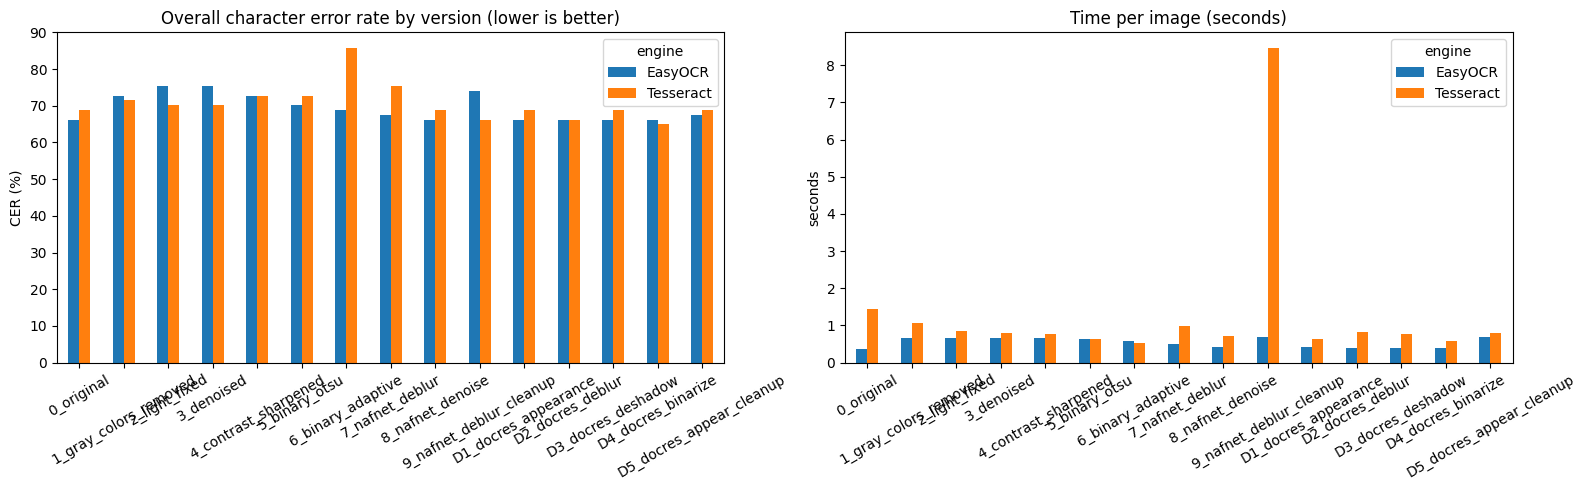

=========== BEST VERSION PER ENGINE ===========

Tesseract: best on 'D4_docres_binarize'
  overall CER : 64.9%
  fields exact: 0/6
  fields wrong: name_bn, name_en, father_bn, mother_bn, dob, nid
  time        : 0.57s

EasyOCR: best on '0_original'
  overall CER : 66.2%
  fields exact: 0/6
  fields wrong: name_bn, name_en, father_bn, mother_bn, dob, nid
  time        : 0.37s

=========== FIELD WINNER (best version of each engine) ===========
  name_bn     Tesseract  64.7%   EasyOCR  64.7%   -> tie
  name_en     Tesseract  70.6%   EasyOCR  76.5%   -> Tesseract
  father_bn   Tesseract  61.5%   EasyOCR  61.5%   -> tie
  mother_bn   Tesseract  63.6%   EasyOCR  63.6%   -> tie
  dob         Tesseract  55.6%   EasyOCR  55.6%   -> tie
  nid         Tesseract  70.0%   EasyOCR  70.0%   -> tie

Note: this is ONE card. Use it to choose settings, not to pick an engine.


In [50]:
# ===== Compare Tesseract vs EasyOCR =====
import re
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 1) Correct answers for THIS card. Check them against the image
#    and edit if anything is wrong. Change them for every new card.
# ---------------------------------------------------------------
GROUND_TRUTH = {
    "name_bn":   "মোঃ সিরাজুল ইসলাম",
    "name_en":   "MD. SIRAZUL ISLAM",
    "father_bn": "আবদুল মোতালেব",
    "mother_bn": "বিবি হালিমা",
    "dob":       "01 Jan 1960",
    "nid":       "866 320 0650",
}

# How each field is cleaned before comparing
def norm_text(s):
    s = unicodedata.normalize("NFC", s)       # same Unicode form for Bangla
    return re.sub(r"\s+", " ", s).strip()

def norm_en(s):
    return norm_text(s).upper()

# OCR sometimes outputs Bangla digits (০১২...) for English ones -> convert
BN_TO_EN_DIGITS = str.maketrans("০১২৩৪৫৬৭৮৯", "0123456789")

def norm_dob(s):
    s = s.translate(BN_TO_EN_DIGITS)
    return re.sub(r"\s+", "", s).lower()      # "01 Jan 1960" -> "01jan1960"

def norm_digits(s):
    s = s.translate(BN_TO_EN_DIGITS)
    return re.sub(r"[^0-9]", "", s)           # keep digits only

FIELD_NORM = {
    "name_bn": norm_text, "name_en": norm_en,
    "father_bn": norm_text, "mother_bn": norm_text,
    "dob": norm_dob, "nid": norm_digits,
}


# ---------------------------------------------------------------
# 2) Find how close the OCR text gets to each field.
#    The field can appear anywhere in the OCR text, so we look for the
#    best-matching piece of the text (edit distance with free start/end).
# ---------------------------------------------------------------
def best_substring_distance(pattern, text):
    m, n = len(pattern), len(text)
    if m == 0:
        return 0
    prev = [0] * (n + 1)                      # starting anywhere in text is free
    for i in range(1, m + 1):
        cur = [i] + [0] * n
        for j in range(1, n + 1):
            cost = 0 if pattern[i - 1] == text[j - 1] else 1
            cur[j] = min(prev[j] + 1, cur[j - 1] + 1, prev[j - 1] + cost)
        prev = cur
    return min(prev)                          # ending anywhere in text is free


def score_text(ocr_text):
    row = {}
    total_errors, total_chars = 0, 0
    for field, truth in GROUND_TRUTH.items():
        f = FIELD_NORM[field]
        t, o = f(truth), f(ocr_text)
        dist = best_substring_distance(t, o)
        row[f"{field}_CER"] = dist / len(t)
        row[f"{field}_exact"] = dist == 0
        total_errors += dist
        total_chars += len(t)
    row["overall_CER"] = total_errors / total_chars
    return row


# ---------------------------------------------------------------
# 3) Build one table with every engine + version
# ---------------------------------------------------------------
rows = []
for engine, results in [("Tesseract", tess_results), ("EasyOCR", easy_results)]:
    for version, r in results.items():
        row = {"engine": engine, "version": version, "time_s": r["time_s"]}
        row.update(score_text(r["text"]))
        rows.append(row)

df = pd.DataFrame(rows)
fields = list(GROUND_TRUTH.keys())
df["fields_exact"] = df[[f"{f}_exact" for f in fields]].sum(axis=1)

# Short summary table (lower CER is better)
summary = df[["engine", "version", "overall_CER", "fields_exact", "time_s"]].copy()
summary["overall_CER"] = (summary["overall_CER"] * 100).round(1).astype(str) + "%"
summary["fields_exact"] = summary["fields_exact"].astype(str) + f"/{len(fields)}"
summary["time_s"] = summary["time_s"].round(2)
print("=========== SUMMARY (CER: lower is better) ===========")
display(summary.sort_values(["engine", "version"]).reset_index(drop=True))

# Per-field error rate (%) for every run
field_cer = df.set_index(["engine", "version"])[[f"{f}_CER" for f in fields]] * 100
field_cer.columns = fields
print("\n=========== PER-FIELD CER (%) ===========")
display(field_cer.round(1))


# ---------------------------------------------------------------
# 4) Charts
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pivot_cer = df.pivot(index="version", columns="engine", values="overall_CER") * 100
pivot_cer.plot(kind="bar", ax=axes[0])
axes[0].set_title("Overall character error rate by version (lower is better)")
axes[0].set_ylabel("CER (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

pivot_time = df.pivot(index="version", columns="engine", values="time_s")
pivot_time.plot(kind="bar", ax=axes[1])
axes[1].set_title("Time per image (seconds)")
axes[1].set_ylabel("seconds")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------
# 5) Best version per engine + short verdict
# ---------------------------------------------------------------
print("=========== BEST VERSION PER ENGINE ===========")
best = {}
for engine in df["engine"].unique():
    sub = df[df["engine"] == engine]
    # All fields count equally: rank by most fields exactly right, then lowest overall CER
    top = sub.sort_values(["fields_exact", "overall_CER"],
                          ascending=[False, True]).iloc[0]
    best[engine] = top
    print(f"\n{engine}: best on '{top['version']}'")
    print(f"  overall CER : {top['overall_CER']*100:.1f}%")
    print(f"  fields exact: {int(top['fields_exact'])}/{len(fields)}")
    wrong = [f for f in fields if not top[f"{f}_exact"]]
    print(f"  fields wrong: {', '.join(wrong) if wrong else 'none'}")
    print(f"  time        : {top['time_s']:.2f}s")

print("\n=========== FIELD WINNER (best version of each engine) ===========")
t, e = best["Tesseract"], best["EasyOCR"]
for f in fields:
    tc, ec = t[f"{f}_CER"] * 100, e[f"{f}_CER"] * 100
    winner = "tie" if abs(tc - ec) < 1e-9 else ("Tesseract" if tc < ec else "EasyOCR")
    print(f"  {f:<10}  Tesseract {tc:5.1f}%   EasyOCR {ec:5.1f}%   -> {winner}")

print("\nNote: this is ONE card. Use it to choose settings, not to pick an engine.")